In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dim = 512
num_samples = 20000
X = np.random.randn(num_samples,dim)

w_gen = np.random.rand(dim)
error = np.random.randn(num_samples) # normally distributed

y = X @ w_gen + 3*error # unscaled errors currently

w_true = np.linalg.lstsq(X,y,rcond=-1)[0]
true_residual = X @ w_true - y

In [3]:
w_init = np.random.rand(X.shape[1])

In [4]:
def train_model(X, y, w, iterations, batch_size, method='vanilla', pbs=False):
    residuals = []
    w_true_conv = []
    w_gen_conv = []
    for i in range(iterations):
        if method == 'vanilla':
            selected_idx = np.random.choice(X.shape[0], size=batch_size)
        elif method == 'rholoss':
            model_residual = X @ w - y
            reducible_loss = model_residual**2 - true_residual**2
            if pbs:
                priorities = np.exp(reducible_loss - np.max(reducible_loss))
                probs = priorities / np.sum(priorities)
                try:
                    selected_idx = np.random.choice(X.shape[0], p=probs, replace=False, size=batch_size)
                except Exception as e:
                    print(priorities)
                    raise RuntimeError(f"Error in Kaczmarz update at iteration {i}: {e}")
            else:
                selected_idx = np.argsort(-reducible_loss)[:batch_size]
        elif method == 'divbs':
            model_residual = X @ w - y
            grads = X * model_residual[:, np.newaxis]
            opt_criterion = model_residual**2 - 2 * model_residual * true_residual
            z_scores = (opt_criterion - opt_criterion.mean()) / opt_criterion.std()
            scores = 1 / (1 + np.exp(z_scores / 16))
            sorted_opt = np.argsort(-opt_criterion)
            opt_ranking = np.array(range(len(sorted_opt)))[sorted_opt]
            grads = grads * scores[:, np.newaxis]
            residual = grads.sum(axis=0).T
            selected_idx = []
            D = grads
            selected_element = []
            for j in range(batch_size):
                correlations = np.abs(D @ residual)
                correlations = correlations / correlations.sum()
                if pbs:
                    idx = np.random.choice(len(D), 1, p=correlations).item()
                else:
                    idx = np.argmax(correlations)
                selected_idx.append(idx)
                if len(selected_element) > 0:
                    selected_element_matrix = np.array(selected_element)
                    D_selected = D[idx, :] - selected_element_matrix.T @ (selected_element_matrix @ D[idx, :])
                else:
                    D_selected = D[idx, :]
                D_selected = D_selected / np.linalg.norm(D_selected)
                selected_element.append(D_selected)
                residual = residual - np.dot(D_selected, residual) * D_selected
        elif method == 'opt':
            model_residual = X @ w - y
            opt_criterion = model_residual**2 - 2 * model_residual * true_residual
            if pbs:
                priorities = np.exp(opt_criterion - np.max(opt_criterion))
                probs = priorities / np.sum(priorities)
                try:
                    selected_idx = np.random.choice(X.shape[0], p=probs, replace=False, size=batch_size)
                except Exception as e:
                    print(priorities)
                    raise RuntimeError(f"Error in Kaczmarz update at iteration {i}: {e}")
            else:
                selected_idx = np.argsort(-opt_criterion)[:batch_size]
        selected_X = X[selected_idx]
        true_b_tau = y[selected_idx]
        model_b_tau = selected_X @ w
        w = w - np.linalg.pinv(selected_X) @ (model_b_tau - true_b_tau)
        residuals.append(np.linalg.norm(X @ w - y))
        w_true_conv.append(np.linalg.norm(w - w_true))
        w_gen_conv.append(np.linalg.norm(w - w_gen))
    return residuals, w_true_conv, w_gen_conv

method: vanilla, residual error: 617.7511295841639
method: rholoss, residual error: 534.274898985363
method: divbs, residual error: 539.1268914811028
method: opt, residual error: 420.9269766034281


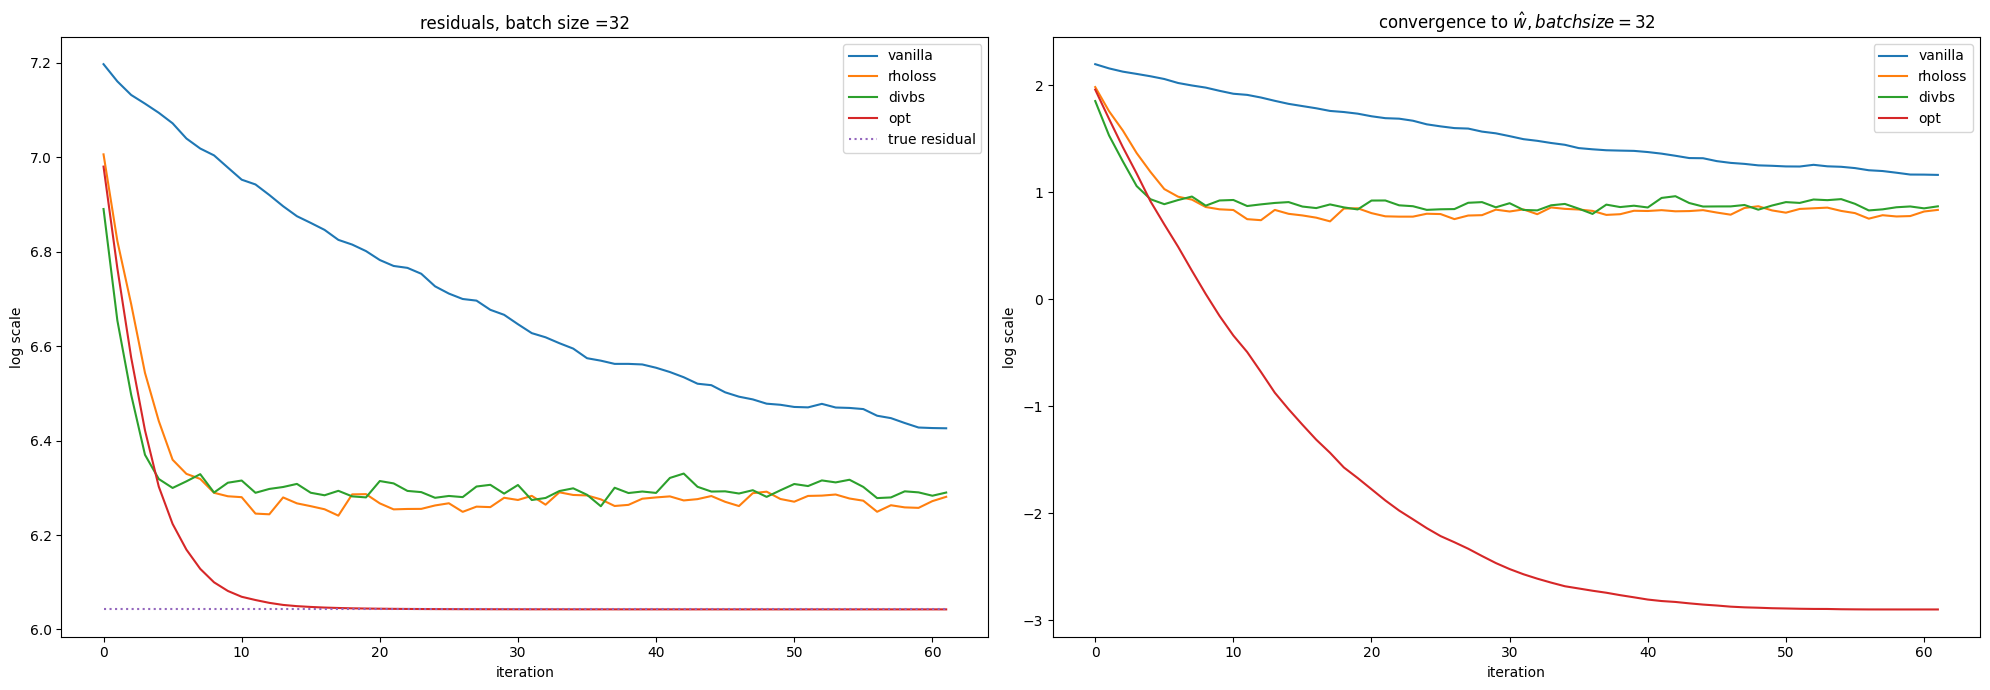

In [5]:
methods = ['vanilla', 'rholoss', 'divbs', 'opt']
k=32
iterations = num_samples // (10*k)
lr = 0.000001
fig, axes = plt.subplots(1,2,figsize=(20,7))
for method in methods:
    residuals, w_true_conv, w_gen_conv = train_model(X,y,w_init.copy(),iterations,k,method=method)
    axes[0].plot(range(iterations), np.log(residuals), label=method)
    axes[1].plot(range(iterations), np.log(w_true_conv), label=method)
    print(f'method: {method}, residual error: {residuals[-1]}')
    axes[0].set_title(f'residuals, batch size ={k}')
    axes[0].set_ylabel('log scale')
    axes[0].set_xlabel('iteration')
    axes[1].set_title(r'convergence to $\hat{w}, batch size =$' + f'{k}')
    axes[1].set_ylabel('log scale')
    axes[1].set_xlabel('iteration')
    axes[1].legend()
axes[0].plot(range(iterations), np.log([np.linalg.norm(true_residual)]*iterations), label='true residual', linestyle=':')
axes[0].legend()
plt.tight_layout()
plt.show()

All three are log scale. $\hat{w}$ is the true solution, whereas $w^*$ was the generating vector before noise was added.

Can we try using the optimal update in our deep learning framework? Also, it appears that PBS opt may do slightly better at the start when sample size is larger.

DivBS consistently outperforms RHO-Loss

Important to note that these are training loss curves, not generalization loss

I have tried the following variatiations with no success:
 - sum together the rankings of opt and the rankings of the correlations and pick one by one in this fashion
 - a prefilter where only the top 320 ranked based on opt are considered and then we perform DivBS on it
 - a weighted DivBS where the gradients are weighted by the opt scores

The only thing that worked well was switching from DivBS to Opt after 3 or so steps